In [2]:
import matplotlib.pyplot as plt 
import pandas as pd

In [5]:
df = pd.read_csv("netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
df.info()
print("-------information-----------")

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
-------information-----------


In [9]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [13]:
df["director"]=df["director"].fillna("Unknown",inplace=True)
df["country"]= df["country"].fillna("Unknown",inplace=True)
df.isnull().sum()

C:\Users\AKSHAY\AppData\Local\Temp\ipykernel_36364\1806599356.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["director"]=df["director"].fillna("Unknown",inplace=True)
C:\Users\AKSHAY\AppData\Local\Temp\ipykernel_36364\1806599356.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chai

show_id           0
type              0
title             0
director          0
cast            825
country           0
date_added       10
release_year      0
rating            4
duration          3
listed_in         0
description       0
dtype: int64

In [17]:
df["date_added"] = pd.to_datetime(df["date_added"],errors="coerce")

In [20]:
df["year_added"] = df["date_added"].dt.year

In [22]:
count = df["type"].value_counts()
print("Value of types : ",count)

Value of types :  type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [27]:
country = df["country"].value_counts().head(10)
print("No by country : \n",country)

No by country : 
 country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [32]:
growth_by_year = df.groupby("year_added")["show_id"].count()
print(growth_by_year)

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: show_id, dtype: int64


In [35]:
genere = df["listed_in"].value_counts().head(10)
print(genere)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

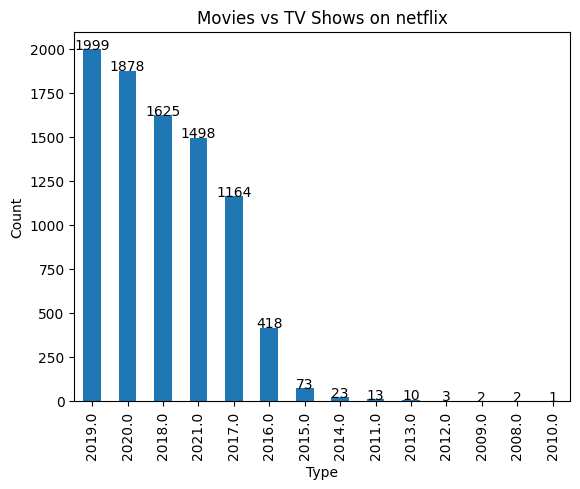

In [38]:
type_count = df["year_added"].value_counts()

ax = type_count.plot(kind="bar")
plt.title("Movies vs TV Shows on netflix")
plt.xlabel("Type")
plt.ylabel("Count")

#Add values on top
for i,v in enumerate(type_count):
    ax.text(i,v,str(v),ha="center")

plt.show

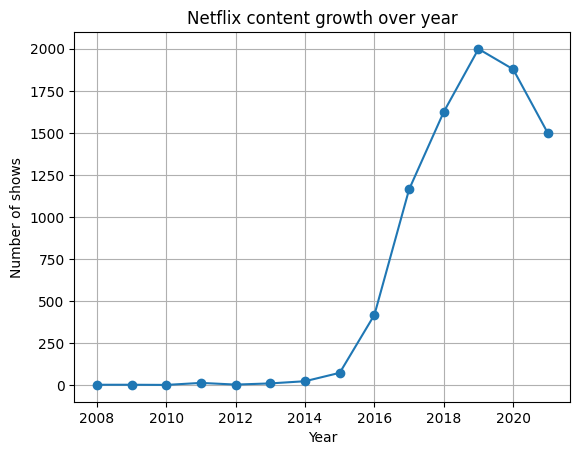

In [40]:
yearly_growth = df.groupby("year_added")["show_id"].count()

yearly_growth.plot(kind="line",marker="o")
plt.title("Netflix content growth over year")
plt.xlabel("Year")
plt.ylabel("Number of shows")
plt.grid()
plt.show()

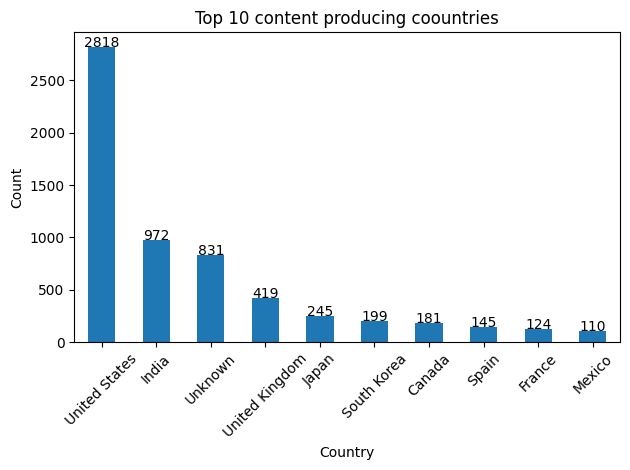

In [42]:
top_countries = df["country"].value_counts().head(10)

ax = top_countries.plot(kind="bar")
plt.title("Top 10 content producing coountries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)

for i,v in enumerate(top_countries):
    ax.text(i,v,str(v),ha="center")

plt.tight_layout()
plt.show()

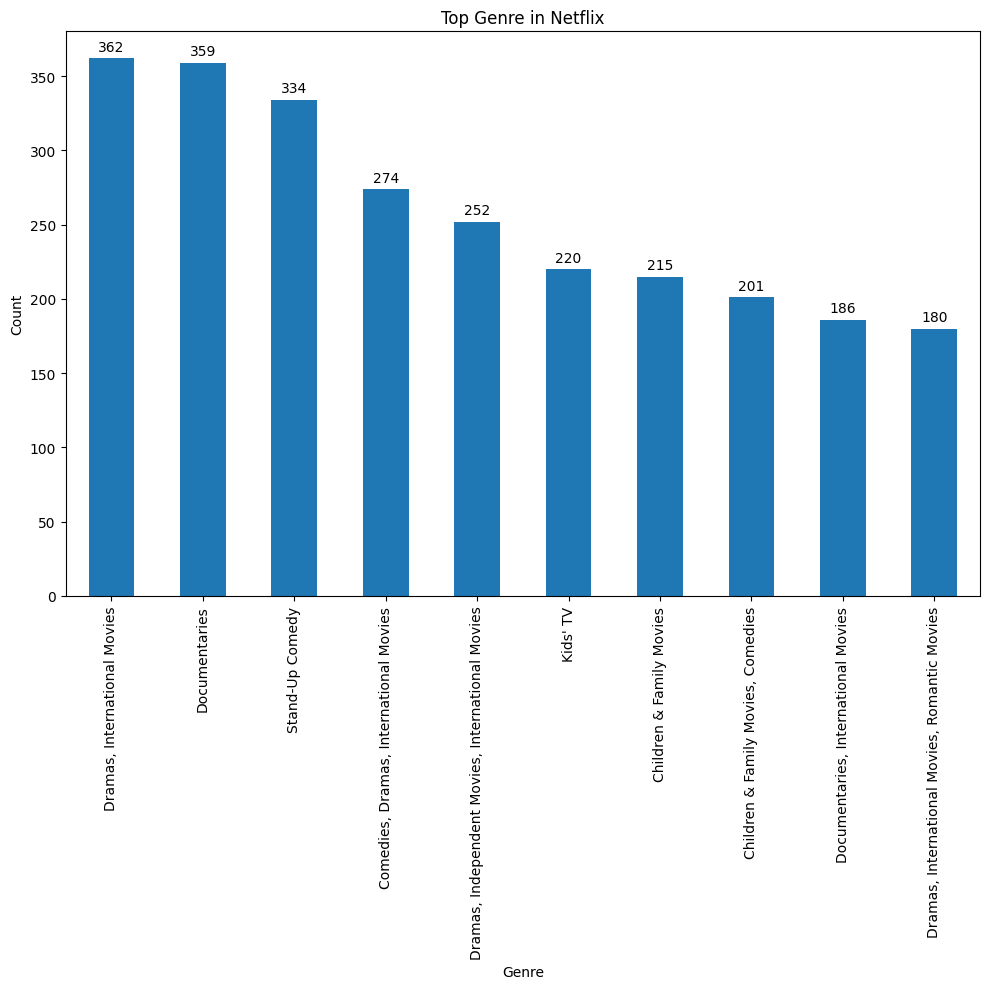

In [50]:
top_genres = df["listed_in"].value_counts().head(10)

plt.figure(figsize=(10,10))
ax = top_genres.plot(kind="bar")
plt.title("Top Genre in Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=90)

for i,v in enumerate(top_genres):
    ax.text(i,v+5,str(v),ha="center")

plt.tight_layout()
plt.show()


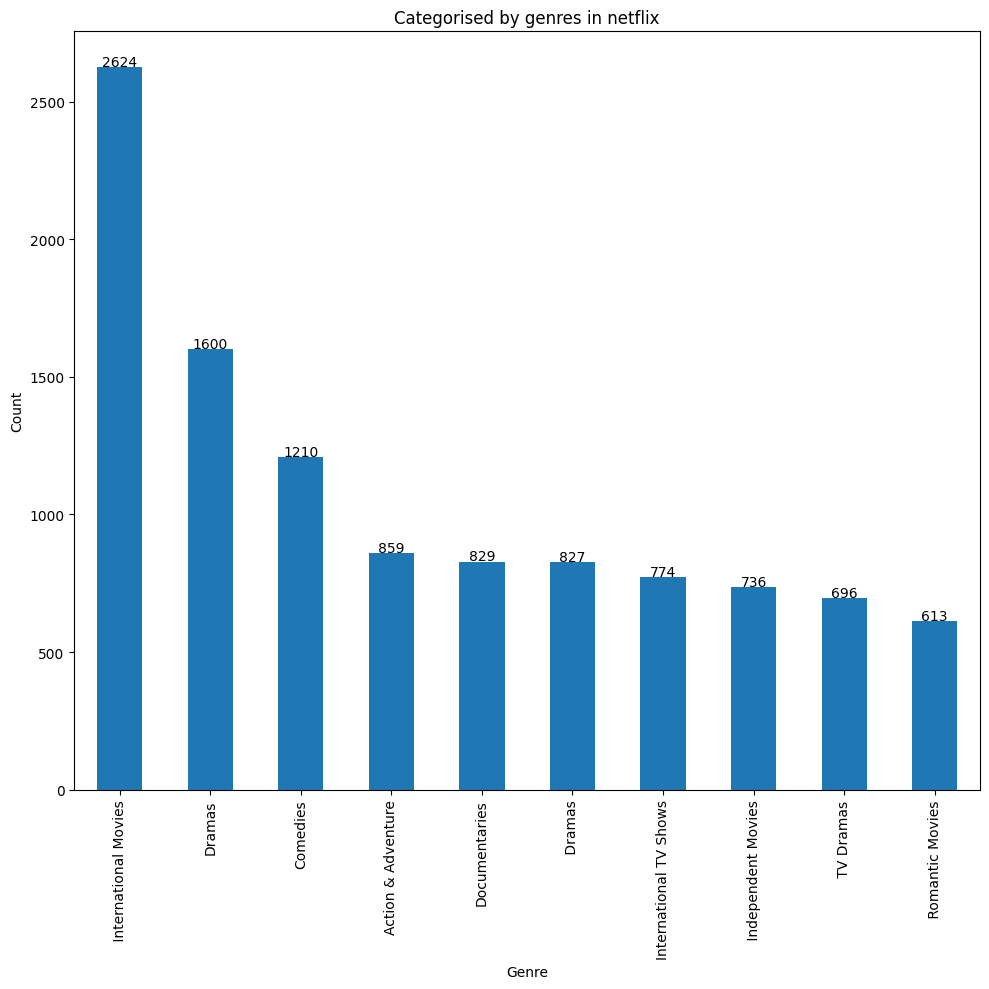

In [65]:
genres = df["listed_in"].str.split(",")

all_genre = [genre for sublist in genres.dropna() for genre in sublist]

genre_series = pd.Series(all_genre)

genre_series_count = genre_series.value_counts().head(10)

plt.figure(figsize=(10,10))
ax = genre_series_count.plot(kind="bar")

plt.title("Categorised by genres in netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.tight_layout()

for i,v in enumerate(genre_series_count):
    ax.text(i,v+4,str(v),ha="center")

plt.show()